# Parametros Globales

In [1]:
# =========================
# Parámetros globales
# =========================

RANDOM_STATE = 42
TEST_SIZE = 0.2

# Métricas
SCORING_REGRESSION = ["rmse", "mae", "r2"]
SCORING_CLASSIFICATION = ["accuracy", "precision", "recall", "f1"]

# KNN
KNN_N_NEIGHBORS = 5
KNN_WEIGHTS = "distance"

# Random Forest
RF_N_ESTIMATORS = 200
RF_MAX_DEPTH = None

# Paths
METRICS_PATH = "models/metrics_summary.csv"

# Librerias

In [2]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

os.makedirs("models", exist_ok=True)

# Importar Dataset

In [3]:
url = "https://raw.githubusercontent.com/ChurnGuard/ChurnInsight/refs/heads/main/data-science/data/final/customer_dataset_for_ml.csv"
database = pd.read_csv(url)

database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 54 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   customer_id                          5000 non-null   object 
 1   age                                  5000 non-null   int64  
 2   membership_years                     5000 non-null   int64  
 3   number_of_children                   5000 non-null   int64  
 4   quantity                             5000 non-null   float64
 5   unit_price                           5000 non-null   float64
 6   avg_purchase_value                   5000 non-null   float64
 7   purchase_frequency                   5000 non-null   float64
 8   avg_discount_used                    5000 non-null   float64
 9   online_purchases                     5000 non-null   int64  
 10  in_store_purchases                   5000 non-null   int64  
 11  total_sales                   

# Correlaciones de Pares

In [4]:
correlation_matrix = database.corr(numeric_only=True)
correlation_pairs = correlation_matrix.abs().unstack()

# Eliminar autocorrelaciones (correlación de una variable consigo misma)
correlation_pairs = correlation_pairs[correlation_pairs.index.get_level_values(0) != correlation_pairs.index.get_level_values(1)]

# Eliminar pares duplicados (A,B) y (B,A)
correlation_pairs = correlation_pairs.drop_duplicates()
top_correlations = correlation_pairs.sort_values(ascending=False)
print(top_correlations.head(50))

avg_purchase_value           total_sales                            0.997180
promotion_effectiveness      promotion_type_no_promotion            0.896817
quantity                     avg_purchase_value                     0.831184
                             total_sales                            0.830526
membership_years             purchase_frequency                     0.766617
quantity                     promotion_effectiveness                0.739325
promotion_effectiveness      days_since_last_purchase               0.738124
total_sales                  promotion_effectiveness                0.645556
quantity                     promotion_type_no_promotion            0.644680
avg_purchase_value           promotion_effectiveness                0.641503
days_since_last_purchase     promotion_type_no_promotion            0.634145
avg_discount_used            in_store_purchases                     0.595408
unit_price                   avg_purchase_value                     0.564881

# Cambios al Dataset

### Features eliminadas



*   customer_id: No aporta valor a la creacion de modelos.
*   transaction_date: Alta correlacion con days_since_last_purchase
*   last_purchase_date: Alta correlación con days_since_last_purchase
*   total_sales: Alta correlación con avg_purchase_value
*   promotion_type_no_promotion: Alta correlacion con promotion_effectiveness






In [5]:
# =========================
# Limpieza de columnas
# =========================

# Copia para no modificar el dataset original
database_clean = database.copy()

# 1. Eliminar columnas no deseadas
columns_to_drop = [
    "customer_id",
    "transaction_date",
    "last_purchase_date",
    "promotion_type_no_promotion",
    "total_sales"
]

database_clean = database_clean.drop(columns=columns_to_drop)

database_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 49 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   age                                  5000 non-null   int64  
 1   membership_years                     5000 non-null   int64  
 2   number_of_children                   5000 non-null   int64  
 3   quantity                             5000 non-null   float64
 4   unit_price                           5000 non-null   float64
 5   avg_purchase_value                   5000 non-null   float64
 6   purchase_frequency                   5000 non-null   float64
 7   avg_discount_used                    5000 non-null   float64
 8   online_purchases                     5000 non-null   int64  
 9   in_store_purchases                   5000 non-null   int64  
 10  total_transactions                   5000 non-null   int64  
 11  total_items_purchased         

# Separacion de Features y Target

In [6]:
TARGET_COLUMN = "churn"

X_features_final = database_clean.drop(columns=[TARGET_COLUMN])
y = database_clean[TARGET_COLUMN]

# Train/Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features_final,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

# Funcion Train_and_Log_model()

In [8]:
def train_and_log_model(
    model,
    model_name: str,
    X_train,
    y_train,
    X_test,
    y_test,
    metrics_path: str = METRICS_PATH
):
    """
    Entrena un modelo, evalúa métricas estándar y las guarda para comparación.
    """

    # Entrenamiento
    model.fit(X_train, y_train)

    # Predicción
    y_pred = model.predict(X_test)

    # Métricas estándar
    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred)
    }

    # Guardado
    metrics_df = pd.DataFrame([metrics])
    metrics_df.to_csv(
        metrics_path,
        mode="a",
        header=not os.path.exists(metrics_path),
        index=False
    )

    return metrics

# KNN


In [9]:
knn = KNeighborsClassifier(
    n_neighbors=KNN_N_NEIGHBORS,
    weights=KNN_WEIGHTS
)

model_name_knn = "knn_v1_baseline"

metrics_knn = train_and_log_model(
    model=knn,
    model_name=model_name_knn,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

metrics_knn

{'model': 'knn_v1_baseline',
 'accuracy': 0.967,
 'precision': 0.9256756756756757,
 'recall': 0.9614035087719298,
 'f1': 0.9432013769363167}

# Random Forest

In [10]:
rf = RandomForestClassifier(
    n_estimators=RF_N_ESTIMATORS,
    max_depth=RF_MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model_name_rf = "rf_v1_baseline"

metrics_rf = train_and_log_model(
    model=rf,
    model_name=model_name_rf,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test
)

metrics_rf

{'model': 'rf_v1_baseline',
 'accuracy': 0.983,
 'precision': 1.0,
 'recall': 0.9403508771929825,
 'f1': 0.969258589511754}

# Comparacion de Modelos

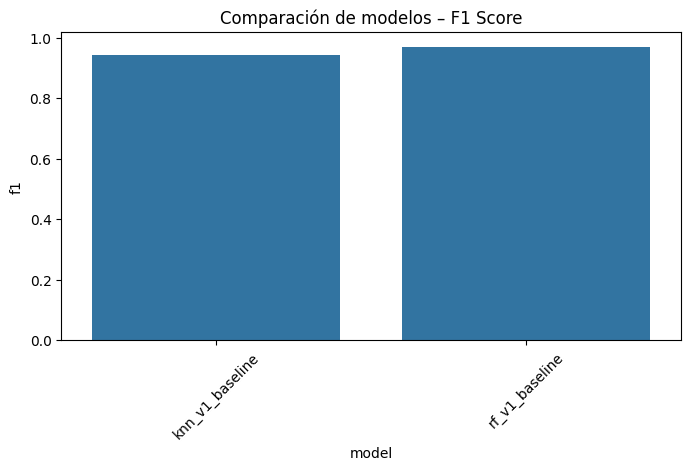

In [11]:
metrics_df = pd.read_csv(METRICS_PATH)
metrics_df

plt.figure(figsize=(8, 4))
sns.barplot(
    data=metrics_df,
    x="model",
    y="f1"
)
plt.title("Comparación de modelos – F1 Score")
plt.xticks(rotation=45)
plt.show()

# Serialización del Modelo Ganador


In [13]:
model_artifact = {
    "model": rf,
    "features": X_train.columns.tolist(),
    "model_name": model_name_rf
}

joblib.dump(
    model_artifact,
    f"models/{model_name_rf}.joblib"
)

['models/rf_v1_baseline.joblib']